In [1]:
import os
import random

import numpy as np
import torch
from peft import LoraConfig, TaskType, get_peft_model
from torch import nn


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


class ModelForSourceCodeEmbedding(nn.Module):
    def __init__(self, model_name, normalize=True):
        super(ModelForSourceCodeEmbedding, self).__init__()
        self.model = AutoModel.from_pretrained(model_name)
        self.normalize = normalize

    def forward(self, **kwargs):
        model_output = self.model(**kwargs)
        embeddings = self.average_pool(model_output, kwargs.get("attention_mask"))
        if self.normalize:
            embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings

    def average_pool(self, model_output, attention_mask):
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return (torch.sum(token_embeddings * input_mask_expanded, 1) /
                torch.clamp(input_mask_expanded.sum(1), min=1e-9))

    def __getattr__(self, name: str):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.model, name)

In [2]:
from transformers import AutoModel, AutoTokenizer


model_name = "microsoft/graphcodebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = ModelForSourceCodeEmbedding(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

C:\Users\bred7\anaconda3\envs\vyatsu_environment\Lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bred7\.cache\huggingface\hub\models--microsoft--graphcodebert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at microsoft/graphcodebert-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION,
    target_modules=["key", "query", "value"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 442,368 || all params: 125,088,000 || trainable%: 0.3536454336147352


In [4]:
torch.cuda.empty_cache()

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [6]:
def get_cosing(q1_embs, q2_embs):
    return torch.sum(q1_embs * q2_embs, axis=1)

def get_loss(cosine_score, labels):
    return torch.mean(torch.square(labels * (1 - cosine_score) + torch.clamp((1 - labels) * cosine_score, min=0.0)))

def threshold(x):
    return 1 if x > 0.5 else 0

In [7]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
from tqdm import tqdm


train_cases = ["case-01", "case-02", "case-03", "case-04", "case-05"]
test_cases = ["case-06", "case-07"]

all_cases = ["case-01", "case-02", "case-03", "case-04", "case-05", "case-06", "case-07"]


def get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths):
    data = []

    for non_plagiarized_file_path in non_plagiarized_files_paths:
        data.append([original_file_path, non_plagiarized_file_path, 0])

    for plagiarized_file_path in plagiarized_files_paths:
        data.append([original_file_path, plagiarized_file_path, 1])

    df = pd.DataFrame(data, columns=["original_code_file", "secondary_code_file", "label"])
    
    return df

def get_paths(case, mode):
    original_file_path = os.path.join("plagiarism_dataset", case, "original", os.listdir(
        f"plagiarism_dataset/{case}/original")[0])

    # get all other cases' files:
    non_plagiarized_files_paths_all = []
    if mode == "train":
        for every_other_case in train_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths
    else:
        for every_other_case in all_cases:
            if every_other_case != case:
                non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join("plagiarism_dataset", every_other_case)) for f in filenames if os.path.splitext(f)[1] == '.java']
                non_plagiarized_files_paths_all += non_plagiarized_files_paths

    # add your own case non-plagiarised files:
    non_plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "non-plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']
    non_plagiarized_files_paths_all += non_plagiarized_files_paths

    plagiarized_files_paths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.path.join(
        "plagiarism_dataset", case, "plagiarized")) for f in filenames if os.path.splitext(f)[1] == '.java']

    return original_file_path, non_plagiarized_files_paths_all, plagiarized_files_paths

In [8]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-01", "train")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-01\original\T1.java
Non-plagiarized
['plagiarism_dataset\\case-02\\non-plagiarized\\01\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\02\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\03\\Nomor2_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\04\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\05\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\06\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\08\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\09\\t02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\11\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\12\\T02.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\13\\No2.java', 'plagiarism_dataset\\case-02\\non-plagiarized\\14\\Soal2.java', 'plagiarism_dataset

In [9]:
original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths("case-06", "test")
print("Original")
print(original_file_path)
print("Non-plagiarized")
print(non_plagiarized_files_paths)
print("Plagiarized")
print(plagiarized_files_paths)

Original
plagiarism_dataset\case-06\original\T6.java
Non-plagiarized
['plagiarism_dataset\\case-01\\non-plagiarized\\01\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\02\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\03\\Nomor1_2451041557A22145B3701B0184109CAB013.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\04\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\05\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\06\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\07\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\08\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\09\\t01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\10\\Main.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\11\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\12\\T01.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\13\\No1.java', 'plagiarism_dataset\\case-01\\non-plagiarized\\14\\Soal1.java', 'plagiarism_dataset

In [10]:
# train-test cycle:
EPOCHS = 100

epochs_losses_train = []
epochs_accuracies_train = []

epochs_losses_test = []
epochs_accuracies_test = []

for epoch in range(EPOCHS):
    train_total_loss = 0
    train_correct = 0
    
    test_total_loss = 0
    test_correct = 0
    
    # train:
    for case in train_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "train")
        train_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_train, y_train = train_df[["original_code_file", "secondary_code_file"]], train_df["label"]
    
        ros = RandomOverSampler(random_state=42)
        X_train, y_train = ros.fit_resample(X_train, y_train)
        
        X_train = X_train.reset_index(drop=True)
        y_train = y_train.reset_index(drop=True)
    
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
        loss = nn.CrossEntropyLoss()
        
        total_loss = 0
        correct = 0
        
        model.train()
        bar = tqdm(range(len(X_train)))
        for i in range(len(X_train)):
            original_code = open(X_train["original_code_file"][i], "r").read()
            secondary_code = open(X_train["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=512, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=512, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_train[i]])
            label = label.to(device)
            
            optimizer.zero_grad()
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            loss_value.backward()
            optimizer.step()
        
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        train_total_loss += total_loss / len(X_train)
        train_correct += correct / len(X_train)

    # test:
    for case in test_cases:
        original_file_path, non_plagiarized_files_paths, plagiarized_files_paths = get_paths(case, "test")
        test_df = get_data(original_file_path, non_plagiarized_files_paths, plagiarized_files_paths)
        test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
        X_test, y_test = test_df[["original_code_file", "secondary_code_file"]], test_df["label"]
    
        total_loss = 0
        correct = 0
        
        model.eval()
        bar = tqdm(range(len(X_test)))
        for i in range(len(X_test)):
            original_code = open(X_test["original_code_file"][i], "r").read()
            secondary_code = open(X_test["secondary_code_file"][i], "r").read()
            
            q1 = tokenizer(original_code, return_tensors="pt", max_length=512, truncation=True)
            q2 = tokenizer(secondary_code, return_tensors="pt", max_length=512, truncation=True)
            
            q1 = {k: v.to(device) for k, v in q1.items()}
            q2 = {k: v.to(device) for k, v in q2.items()}
            
            label = torch.tensor([y_test[i]])
            label = label.to(device)
            
            q1 = model(**q1)
            q2 = model(**q2)
            loss_value = get_loss(get_cosing(q1, q2).to(device), label)
            total_loss += loss_value.item()
            
            prediction = threshold(get_cosing(q1, q2).item())
            if prediction == label:
                correct += 1
            bar.update(1)
        
        test_total_loss += total_loss / len(X_test)
        test_correct += correct / len(X_test)
    
    epochs_losses_train.append(train_total_loss / 5)
    print(f"Epoch: {epoch}, Loss train: {train_total_loss / 5}")
    epochs_accuracies_train.append(train_correct / 5)
    print(f"Epoch: {epoch}, Accuracy train: {train_correct / 5}")
    
    epochs_losses_test.append(test_total_loss / 2)
    print(f"Epoch: {epoch}, Loss test: {test_total_loss / 2}")
    epochs_accuracies_test.append(test_correct / 2)
    print(f"Epoch: {epoch}, Accuracy test: {test_correct / 2}")

    torch.save(model, f"models_graphcodebert/{epoch + 1}_emb_model.pth")

  0%|          | 0/584 [00:00<?, ?it/s]C:\Users\bred7\anaconda3\envs\vyatsu_environment\Lib\site-packages\transformers\models\roberta\modeling_roberta.py:370: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
100%|██████████| 584/584 [01:10<00:00,  8.26it/s]

100%|██████████| 560/560 [01:48<00:00,  5.16it/s]

100%|██████████| 558/558 [01:16<00:00,  7.33it/s]

100%|██████████| 466/466 [00:32<00:00, 14.44it/s]

Epoch: 0, Loss train: 0.17955287039450435
Epoch: 0, Accuracy train: 0.7190925213241439
Epoch: 0, Loss test: 0.23698635317022942
Epoch: 0, Accuracy test: 0.5901287553648069



100%|██████████| 466/466 [00:34<00:00, 13.62it/s]

100%|██████████| 556/556 [01:16<00:00,  7.25it/s]

100%|██████████| 556/556 [01:05<00:00,  8.48it/s]

100%|██████████| 466/466 [00:31<00:00, 14.72it/s]

100%|██████████| 466/466 [00:32<00:00, 14.24it/s]

Epoch: 1, Loss train: 0.04840402981248722
Epoch: 1, Accuracy train: 0.9527513312877254
Epoch: 1, Loss test: 0.14014947707831632
Epoch: 1, Accuracy test: 0.8733905579399142


100%|██████████| 584/584 [01:05<00:00,  8.86it/s]

100%|██████████| 560/560 [01:48<00:00,  5.17it/s]

100%|██████████| 558/558 [01:14<00:00,  7.49it/s]

100%|██████████| 466/466 [00:32<00:00, 14.50it/s]

...

100%|██████████| 584/584 [01:05<00:00,  8.94it/s]

100%|██████████| 560/560 [01:48<00:00,  5.18it/s]

100%|██████████| 558/558 [01:14<00:00,  7.49it/s]

100%|██████████| 466/466 [00:32<00:00, 14.22it/s]

Epoch: 88, Loss train: 0.00021028506062701502
Epoch: 88, Accuracy train: 0.9996575342465753
Epoch: 88, Loss test: 0.13426374672102825
Epoch: 88, Accuracy test: 0.7800429184549356



100%|██████████| 466/466 [00:34<00:00, 13.58it/s]

100%|██████████| 556/556 [01:15<00:00,  7.39it/s]

100%|██████████| 556/556 [01:04<00:00,  8.60it/s]

100%|██████████| 466/466 [00:31<00:00, 14.78it/s]

100%|██████████| 466/466 [00:32<00:00, 14.19it/s]

Epoch: 89, Loss train: 6.212146073036286e-05
Epoch: 89, Accuracy train: 1.0
Epoch: 89, Loss test: 0.1310250909848404
Epoch: 89, Accuracy test: 0.7854077253218884


RuntimeError: [enforce fail at inline_container.cc:595] . unexpected pos 126224000 vs 126223888

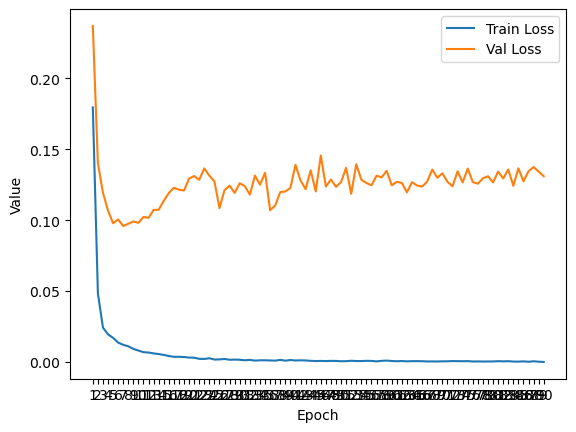

In [11]:
import matplotlib.pyplot as plt
EPOCHS = 90
plt.plot(range(1, EPOCHS + 1), epochs_losses_train, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), epochs_losses_test, label="Val Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

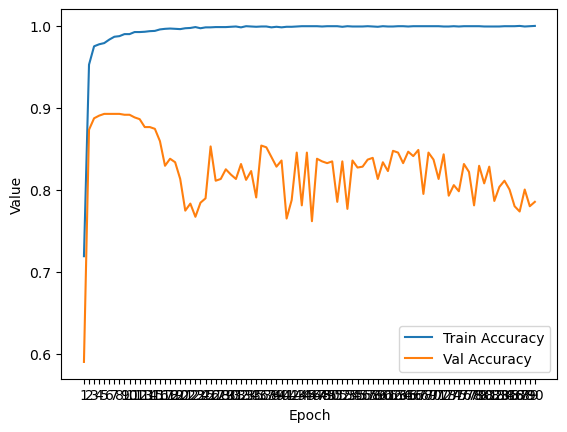

In [12]:
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_train, label="Train Accuracy")
plt.plot(range(1, EPOCHS + 1), epochs_accuracies_test, label="Val Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

In [13]:
# torch.save(model, "models_codebert/code_embedding_model.pth")

In [14]:
# model = torch.load("code_embedding_model.pth")
# model.eval()

In [15]:
epochs_losses_test, len(epochs_losses_test)

([0.23698635317022942,
  0.14014947707831632,
  0.11933230620801122,
  0.10677640364500779,
  0.09784443312176096,
  0.10050952748510528,
  0.09589666318965234,
  0.09746931283675718,
  0.09912669168435145,
  0.09813037627084271,
  0.1023281467665845,
  0.10164322735513831,
  0.10724298691608801,
  0.10736079946653902,
  0.11364276760912859,
  0.11913005010581812,
  0.12284726895492074,
  0.12151592925010751,
  0.12091770747549727,
  0.12932336045729895,
  0.13114939001176548,
  0.1284585205541131,
  0.13651499077285667,
  0.1313482648645655,
  0.12744966795608903,
  0.10852312069021852,
  0.12122238574225103,
  0.12435146934520669,
  0.11923506973939199,
  0.12605471345499872,
  0.12404407159661579,
  0.11800946189786418,
  0.13148585415934155,
  0.1250332466889321,
  0.1334152892828246,
  0.10700586327158086,
  0.11041324047846804,
  0.11985725543909875,
  0.1202721458975474,
  0.12276340529551028,
  0.13903977080905583,
  0.12796819873974252,
  0.12192072168470863,
  0.1352197278960

In [16]:
epochs_accuracies_test, len(epochs_accuracies_test)

([0.5901287553648069,
  0.8733905579399142,
  0.8873390557939914,
  0.890557939914163,
  0.8927038626609443,
  0.8927038626609443,
  0.8927038626609443,
  0.8927038626609443,
  0.8916309012875536,
  0.8916309012875536,
  0.8884120171673819,
  0.8862660944206009,
  0.8766094420600858,
  0.8766094420600858,
  0.8744635193133047,
  0.8594420600858369,
  0.8293991416309012,
  0.8379828326180258,
  0.8336909871244635,
  0.8133047210300429,
  0.7746781115879828,
  0.7832618025751072,
  0.7671673819742488,
  0.7843347639484979,
  0.7896995708154506,
  0.8530042918454935,
  0.8111587982832618,
  0.8133047210300429,
  0.8251072961373391,
  0.8186695278969958,
  0.8133047210300429,
  0.8315450643776824,
  0.8122317596566524,
  0.822961373390558,
  0.7907725321888412,
  0.8540772532188841,
  0.851931330472103,
  0.8401287553648069,
  0.8283261802575108,
  0.8358369098712446,
  0.7650214592274678,
  0.7875536480686696,
  0.8454935622317596,
  0.7811158798283262,
  0.8454935622317596,
  0.761802575

In [17]:
print(f"Max accuracy: {max(epochs_accuracies_test)} at epoch {epochs_accuracies_test.index(max(epochs_accuracies_test)) + 1}")
print(f"Min loss: {min(epochs_losses_test)} at epoch {epochs_losses_test.index(min(epochs_losses_test)) + 1}")

Max accuracy: 0.8927038626609443 at epoch 5
Min loss: 0.09589666318965234 at epoch 7
